# The Fama-French Three-Factor Model

Fama and French (1992, 1993) documented two additional return premia and built them into factors:

$$r_i - r_f = \alpha_i + \beta_i^{\text{MKT}}(r_m - r_f) + \beta_i^{\text{SMB}} \cdot \text{SMB} + \beta_i^{\text{HML}} \cdot \text{HML} + \epsilon_i$$

**SMB (Small Minus Big):** Return of a portfolio long small-cap stocks and short large-cap stocks. Captures the empirically documented **size premium** — small caps have historically outperformed large caps on a risk-adjusted basis.

**HML (High Minus Low):** Return of a portfolio long high book-to-market (value) stocks and short low book-to-market (growth) stocks. Captures the **value premium** — value stocks have historically outperformed growth stocks.

Each factor is a **tradeable return spread** constructed from real portfolios. Factor data is freely available from Kenneth French's data library.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

from src.factor_model import fetch_factor_data, fit_factor_model, compute_factor_attribution
from src.time_series import fetch_returns

/Users/basava/Documents/git/Claude_finance/bs_pricer/.claude_finance/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# fetch returns and factors for same period
spy_returns = fetch_returns("SPY", start="2023-01-01", end="2026-04-01")
aapl_returns = fetch_returns("AAPL", start="2023-01-01", end="2026-04-01")
factors = fetch_factor_data(start="2023-01-01", end="2026-04-01")



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/Users/basava/Documents/git/Claude_finance/bs_pricer/notebooks/../src/factor_model.py:25: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  factors = pdr.get_data_famafrench(


In [3]:
# fit models
spy_model = fit_factor_model(spy_returns, factors)
aapl_model = fit_factor_model(aapl_returns, factors)

In [4]:
# print comparison
print("SPY Factor Model:")
print(f"  Alpha:     {spy_model['alpha']:.4f} (p={spy_model['alpha_p_value']:.3f})")
print(f"  Beta_mkt:  {spy_model['betas']['Mkt-RF']:.4f}")
print(f"  Beta_smb:  {spy_model['betas']['SMB']:.4f}")
print(f"  Beta_hml:  {spy_model['betas']['HML']:.4f}")
print(f"  R²:        {spy_model['r_squared']:.4f}")

print("\nAAPL Factor Model:")
print(f"  Alpha:     {aapl_model['alpha']:.4f} (p={aapl_model['alpha_p_value']:.3f})")
print(f"  Beta_mkt:  {aapl_model['betas']['Mkt-RF']:.4f}")
print(f"  Beta_smb:  {aapl_model['betas']['SMB']:.4f}")
print(f"  Beta_hml:  {aapl_model['betas']['HML']:.4f}")
print(f"  R²:        {aapl_model['r_squared']:.4f}")

SPY Factor Model:
  Alpha:     0.0121 (p=0.000)
  Beta_mkt:  0.9927
  Beta_smb:  -0.0898
  Beta_hml:  -0.0077
  R²:        0.9940

AAPL Factor Model:
  Alpha:     0.0195 (p=0.638)
  Beta_mkt:  1.1199
  Beta_smb:  -0.2496
  Beta_hml:  -0.1435
  R²:        0.4587


**SPY Factor Model**
*   **$\beta_{\text{mkt}} = 0.9927$:** This is almost exactly 1.0, as expected. SPY moves in near-perfect lockstep with the overall market.
*   **$\beta_{\text{smb}} = -0.090$:** This coefficient is negative, as expected. When small-cap stocks outperform, it slightly hurts SPY.
*   **$\beta_{\text{hml}} = -0.008$:** This value is essentially zero, indicating that SPY remains neutral regarding value versus growth because it holds both types of assets.
*   **$R^2 = 0.994$:** This is an extraordinary result. Just three factors explain 99.4% of SPY's daily return variance, leaving almost nothing unexplained. This confirms that SPY serves as a pure systematic exposure vehicle.
*   **$\alpha = 0.0121\%$ per day ($p=0.000$):** This alpha is statistically significant. Annualized, it equals approximately 3.0% ($0.0121\% \times 252 \approx 3.0\%$). This seems surprisingly large, as SPY should not possess alpha over the Fama-French factors by construction. A likely caveat is that SPY reinvests dividends, whereas the Fama-French market factor may not fully account for this.

**AAPL Factor Model**
*   **$\beta_{\text{mkt}} = 1.120$:** AAPL amplifies broader market movements, meaning a 1% market move translates to a 1.12% move for AAPL. It carries higher systematic risk than SPY.
*   **$\beta_{\text{smb}} = -0.250$:** This exposure is notably more negative than SPY's. Since AAPL is the largest company in the world, it represents an extreme large-cap stock, making this result logical.
*   **$\beta_{\text{hml}} = -0.144$:** This indicates a negative value exposure. AAPL is fundamentally a growth stock with a low book-to-market ratio, so a negative HML coefficient is expected.
*   **$R^2 = 0.459$:** Only 46% of AAPL's variance is explained by the three factors. The remaining 54% is idiosyncratic, driven by company-specific news, product cycles, regulatory risks, and other unique factors. This aligns exactly with financial theory.
*   **$\alpha = 0.0195\%$ per day ($p=0.638$):** This value is not statistically significant. A p-value of 0.638 indicates there is a 63.8% probability that this alpha is purely noise, meaning AAPL has no statistically significant risk-adjusted excess return over this period.

### Factor Attribution

Total return is decomposed into factor contributions:

$$\bar{r}_{\text{total}} = \alpha + \beta_{\text{MKT}} \cdot \bar{r}_{\text{MKT}} + \beta_{\text{SMB}} \cdot \bar{r}_{\text{SMB}} + \beta_{\text{HML}} \cdot \bar{r}_{\text{HML}} + \bar{\epsilon}$$

Each component is `beta × mean factor return` over the period. This answers: *how much of this asset's return came from market exposure vs size exposure vs value exposure vs genuine skill (alpha)?*

In [5]:
spy_attribution = compute_factor_attribution(
    spy_returns, 
    factors.drop(columns=['RF']),
    spy_model['betas'],
    spy_model['alpha']
)

aapl_attribution = compute_factor_attribution(
    aapl_returns,
    factors.drop(columns=['RF']),
    aapl_model['betas'],
    aapl_model['alpha']
)

print("SPY Attribution (daily %):")
for k, v in spy_attribution.items():
    print(f"  {k}: {v:.6f}")

print("\nAAPL Attribution (daily %):")
for k, v in aapl_attribution.items():
    print(f"  {k}: {v:.6f}")

SPY Attribution (daily %):
  r_total: 0.071108
  r_alpha: 0.012055
  r_mkt: 0.056780
  r_SMB: 0.001601
  r_HML: 0.000018
  epsilon: 0.000654

AAPL Attribution (daily %):
  r_total: 0.089106
  r_alpha: 0.019526
  r_mkt: 0.064055
  r_SMB: 0.004451
  r_HML: 0.000334
  epsilon: 0.000740


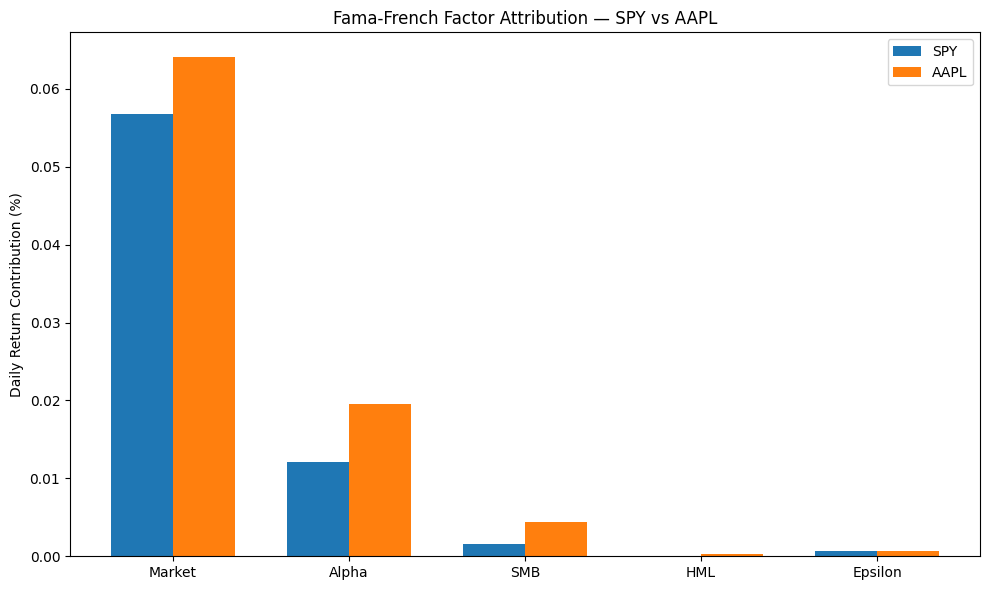

In [6]:
components = ['r_mkt', 'r_alpha', 'r_SMB', 'r_HML', 'epsilon']
labels = ['Market', 'Alpha', 'SMB', 'HML', 'Epsilon']

spy_vals  = [spy_attribution[c] for c in components]
aapl_vals = [aapl_attribution[c] for c in components]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, spy_vals,  width, label='SPY')
ax.bar(x + width/2, aapl_vals, width, label='AAPL')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Daily Return Contribution (%)')
ax.set_title('Fama-French Factor Attribution — SPY vs AAPL')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../results/06_factor_attribution.png', dpi=150)
plt.show()